## **Figure-S11**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pyopenms as po
sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("pyopenms version", po.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
pyopenms version 3.3.0
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
custom_palette = ["tab:cyan", "tab:brown"]
sns.set_palette(custom_palette)

---

---

In [4]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF\n2024',
             panhuman='PanHuman\n2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

In [5]:
# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}


# **Load Data**

### **Identification Rates**

In [6]:
diann_1ng = { n:defaultdict(dict) for n in names.values() }
diann_5ng = { n:defaultdict(dict) for n in names.values() }
diann_25ng = { n:defaultdict(dict) for n in names.values() }
diann_100ng = { n:defaultdict(dict) for n in names.values() }

osw_1ng = { n:defaultdict(dict) for n in names.values() }
osw_5ng = { n:defaultdict(dict) for n in names.values() }
osw_25ng = { n:defaultdict(dict) for n in names.values() }
osw_100ng = { n:defaultdict(dict) for n in names.values() }

##### **DIA-NN Results**

In [7]:
# Bruker data
diann_1ng[names['bruker']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann_1ng[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann_1ng[names['bruker']][condition['refined'] + '_5ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann_1ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")


# Silico data
diann_1ng[names['silico']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann_1ng[names['silico']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann_1ng[names['silico']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann_1ng[names['silico']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")



# DiaTracer data
diann_1ng[names['diatracer']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-diaTracer/diann/1ng/report.tsv")
diann_1ng[names['diatracer']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/100ng_lib/report.tsv")
diann_1ng[names['diatracer']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/5ng_lib/report.tsv")
diann_1ng[names['diatracer']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/25ng_lib/report.tsv")


# Experimental data
diann_1ng[names['exp']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann_1ng[names['exp']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann_1ng[names['exp']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann_1ng[names['exp']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)



# PanHuman data
diann_1ng[names['panhuman']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann_1ng[names['panhuman']][condition['refined'] + '25ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann_1ng[names['panhuman']][condition['refined'] + '_5ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann_1ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv


Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 13946 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 47 MB (working set delta), 47 MB (peak working set delta)


Aho-Corasick done:
  found 14201 hits for 13946 of 13946 peptides.
Peptide hits passing enzyme filter: 14201
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 13946 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both 

In [8]:
# Bruker data
diann_5ng[names['bruker']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/report.tsv")
diann_5ng[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/5ng/25ng_lib/report.tsv")
diann_5ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/5ng/100ng_lib/report.tsv")


# Silico data
diann_5ng[names['silico']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/report.tsv")
diann_5ng[names['silico']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/5ng/25ng_lib/report.tsv")
diann_5ng[names['silico']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/5ng/100ng_lib/report.tsv")



# DiaTracer data
diann_5ng[names['diatracer']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-diaTracer/diann/5ng/report.tsv")
diann_5ng[names['diatracer']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/5ng/100ng_lib/report.tsv")
diann_5ng[names['diatracer']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/5ng/25ng_lib/report.tsv")


# Experimental data
diann_5ng[names['exp']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/report.tsv", infer_schema_length=1000)
diann_5ng[names['exp']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/5ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann_5ng[names['exp']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/5ng/100ng_lib/report.tsv", infer_schema_length=1000)



# PanHuman data
diann_5ng[names['panhuman']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/report.tsv")
diann_5ng[names['panhuman']][condition['refined'] + '25ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/5ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann_5ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/5ng/100ng_lib/report.tsv", infer_schema_length=1000)

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/report.tsv
Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 27716 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 30 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 28109 hits for 27716 of 27716 peptides.
Peptide hits passing enzyme filter: 28109
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %

In [9]:
# Bruker data
diann_25ng[names['bruker']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/report.tsv")
diann_25ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-Bruker-Refined-Analysis/diann/25ng/100ng_lib/report.tsv")


# Silico data
diann_25ng[names['silico']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/report.tsv")
diann_25ng[names['silico']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/25ng/100ng_lib/report.tsv")


# DiaTracer data
diann_25ng[names['diatracer']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-diaTracer/diann/25ng/report.tsv")
diann_25ng[names['diatracer']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-K562-diaTracer-Refinement/diann/25ng/100ng_lib/report.tsv")


# Experimental data
diann_25ng[names['exp']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/report.tsv", infer_schema_length=1000)
diann_25ng[names['exp']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann_matcher("../../results/Dilutions-Exp-Refined-Analysis/diann/25ng/100ng_lib/report.tsv", infer_schema_length=1000)

# PanHuman data
diann_25ng[names['panhuman']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/report.tsv")
diann_25ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSetDiann_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/diann/25ng/100ng_lib/report.tsv", infer_schema_length=1000)

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/report.tsv
Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 50776 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 106 MB (working set delta), 48 MB (peak working set delta)


Aho-Corasick done:
  found 51429 hits for 50776 of 50776 peptides.
Peptide hits passing enzyme filter: 51429
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (

In [10]:
# Bruker data
diann_100ng[names['bruker']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/report.tsv")


# Silico data
diann_100ng[names['silico']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/report.tsv")


# DiaTracer data
diann_100ng[names['diatracer']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-diaTracer/diann/100ng/report.tsv")


# Experimental data
diann_100ng[names['exp']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/report.tsv", infer_schema_length=1000)

# PanHuman data
diann_100ng[names['panhuman']][condition['orig']] = getProteinSetDiann_matcher("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/report.tsv")

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/report.tsv
Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 74608 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 130 MB (working set delta), 50 MB (peak working set delta)


Aho-Corasick done:
  found 75402 hits for 74608 of 74608 peptides.
Peptide hits passing enzyme filter: 75402
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 

#### **OSW Results**

In [11]:
# Bruker data
osw_1ng[names['bruker']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw_1ng[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw_1ng[names['bruker']][condition['refined'] + '_5ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw_1ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# Silico data
osw_1ng[names['silico']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['silico']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['silico']][condition['refined'] + '_5ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['silico']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

# DiaTracer data
osw_1ng[names['diatracer']][condition['orig']] = getProteinSet_orig_matcher("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_LDA/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw_1ng[names['diatracer']][condition['refined'] + '_25ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/25ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw_1ng[names['diatracer']][condition['refined'] + '_5ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/5ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw_1ng[names['diatracer']][condition['refined'] + '_100ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/100ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")


# Experimental data
osw_1ng[names['exp']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['exp']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw_1ng[names['exp']][condition['refined'] + '_5ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw_1ng[names['exp']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# PanHuman data
osw_1ng[names['panhuman']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['panhuman']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['panhuman']][condition['refined'] + '_5ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw_1ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq


PeptideIndexer found unmatched peptides, which could not be associated to a protein.
<Unable to determine decoy string (not enough occurrences; <40%)!> occurred 51 times
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 12474 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 15121 hits for 12469 of 12474 peptides.
Peptide hits passing enzyme filter: 15121
     ... rejected by enzyme filter: 0
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: DDLGNTLEK
Unmatched peptide: EIAQSFLGK
Unmatched peptide: QTAEAYLGK
-----------------------------------
Peptide statistics

  

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 21618 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 18 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 25465 hits for 21610 of 21618 peptides.
Peptide hits passing enzyme filter: 25465
     ... rejected by enzyme filter: 0
Unmatched peptide: EIAQSFLGK
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: QTAEAYLGK
Unmatched peptide: ARFEELNNDLFR
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide:

...

Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 18496 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 22139 hits for 18490 of 18496 peptides.
Peptide hits passing enzyme filter: 22139
     ... rejected by enzyme filter: 0
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: EIAQSFLGK
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: DDLGNTLEK
Unmatched peptide: QTAEAYLGK
----------------------

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 20288 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 23966 hits for 20280 of 20288 peptides.
Peptide hits passing enzyme filter: 23966
     ... rejected by enzyme filter: 0
Unmatched peptide: EIAQSFLGK
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: ARFEELNNDLFR
Unmatched peptide: QTAEAYLGK
Unmatched peptide: DDLGNTLEK
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: DAG

Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 6525 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 7777 hits for 6525 of 6525 peptides.
Peptide hits passing enzyme filter: 7777
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 6525 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both         

In [12]:
# Bruker data
osw_5ng[names['bruker']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")
osw_5ng[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/5ng/5ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")
osw_5ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/5ng/5ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")


# Silico data
osw_5ng[names['silico']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_LDA_XGBoost/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq/")
osw_5ng[names['silico']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/5ng/5ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq/")
osw_5ng[names['silico']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/5ng/5ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq/")

# DiaTracer data
osw_5ng[names['diatracer']][condition['orig']] = getProteinSet_orig_matcher("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_LDA/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.parquet")
osw_5ng[names['diatracer']][condition['refined'] + '_25ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/25ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.parquet")
osw_5ng[names['diatracer']][condition['refined'] + '_100ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/100ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.parquet")

# Experimental data
osw_5ng[names['exp']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")
osw_5ng[names['exp']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/5ng/5ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")
osw_5ng[names['exp']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/5ng/5ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")

# PanHuman data
osw_5ng[names['panhuman']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq/")
osw_5ng[names['panhuman']][condition['refined'] + '_25ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/5ng/5ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")
osw_5ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/5ng/5ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-5ng_DIA_Slot1-4_1_551_3-8-2021.oswpq
Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 23554 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 27641 hits for 23548 of 23554 peptides.
Peptide hits passing enzyme filter: 27641
     ... rejected by enzyme filter: 0
Unmatched peptide: DAGTIA

PeptideIndexer found unmatched peptides, which could not be associated to a protein.
<Unable to determine decoy string (not enough occurrences; <40%)!> occurred 17 times
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 34868 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 39815 hits for 34858 of 34868 peptides.
Peptide hits passing enzyme filter: 39815
     ... rejected by enzyme filter: 0
Unmatched peptide: ARFEELNNDLFR
Unmatched peptide: DDLGNTLEK
Unmatched peptide: QTAEAYLGK
Unmatched peptide: TQVNTQAEQLR
Unmatched peptide: EIAQSFLGK
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: DAGTIAGL

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.
Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the p

Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 35898 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 40969 hits for 35888 of 35898 peptides.
Peptide hits passing enzyme filter: 40969
     ... rejected by enzyme filter: 0
Unmatched peptide: EIAQSFLGK
Unmatched peptide: DDLGNTLEK
Unmatched peptide: LMQGFNEDMAIEAQQK
Unmatched peptide: QTVEAGVNGLCR
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: ARFEELNNDLFR
Unmatched pepti

Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 19563 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 22000 hits for 19563 of 19563 peptides.
Peptide hits passing enzyme filter: 22000
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 19563 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both   

In [13]:
# Bruker data
osw_25ng[names['bruker']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")
osw_25ng[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Bruker-Refined-Analysis/osw/25ng/25ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")

# Silico data
osw_25ng[names['silico']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")
osw_25ng[names['silico']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/25ng/25ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")

# DiaTracer data
osw_25ng[names['diatracer']][condition['orig']] = getProteinSet_orig_matcher("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_LDA/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.parquet")
osw_25ng[names['diatracer']][condition['refined'] + '_100ngLib'] = getProteinSet_orig_matcher("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/100ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.parquet")

# Experimental data
osw_25ng[names['exp']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq")
osw_25ng[names['exp']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-Exp-Refined-Analysis/osw/25ng/25ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")

# PanHuman data
osw_25ng[names['panhuman']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")
osw_25ng[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSet_matcher("../../results/Dilutions-PanHuman-Refined-Analysis/osw/25ng/25ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-25ng_DIA_Slot1-5_1_550_3-7-2021.oswpq/


PeptideIndexer found unmatched peptides, which could not be associated to a protein.
<Unable to determine decoy string (not enough occurrences; <40%)!> occurred 13 times
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 45281 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 0 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 50975 hits for 45271 of 45281 peptides.
Peptide hits passing enzyme filter: 50975
     ... rejected by enzyme filter: 0
Unmatched peptide: LMQGFNEDMAIEAQQK
Unmatched peptide: QTAEAYLGK
Unmatched peptide: ARFEELNNDLFR
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: EIAQSFLGK
Unmatched peptide: DAGTIAGLNIVR
Unmatched pepti

Unable to determine decoy string (not enough occurrences; <40%)!
PeptideIndexer found unmatched peptides, which could not be associated to a protein.
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 56852 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 41 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 63214 hits for 56837 of 56852 peptides.
Peptide hits passing enzyme filter: 63214
     ... rejected by enzyme filter: 0
Unmatched peptide: EQSFTSLEVR
Unmatched peptide: DAGTIAGLNVIR
Unmatched peptide: QTVEAGVNGLCR
Unmatched peptide: DAGTIAGLNIVR
Unmatched peptide: IVNEPTAAAIAYGLDK
Unmatched peptide: TQVNTQAEQLR
Unmatched pepti

Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 39708 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.00 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 8 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 44214 hits for 39708 of 39708 peptides.
Peptide hits passing enzyme filter: 44214
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 39708 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both   

In [14]:
# Bruker data
osw_100ng[names['bruker']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.oswpq/")

# Silico data
osw_100ng[names['silico']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.oswpq/")

# DiaTracer data
osw_100ng[names['diatracer']][condition['orig']] = getProteinSet_orig_matcher("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.parquet")

# Experimental data
osw_100ng[names['exp']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.oswpq/")

# PanHuman data
osw_100ng[names['panhuman']][condition['orig']] = getProteinSet_matcher("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.oswpq/")


../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-100ng_DIA_Slot1-5_1_549_3-7-2021.oswpq/
Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 64212 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.01 s (CPU), 0.00 s (system), 0.01 s (user)
Memory usage (Aho-Corasick): 52 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 71022 hits for 64196 of 64212 peptides.
Peptide hits passing enzyme filter: 71022
     ... rejected by enzyme filter: 0
Unmatched peptide: 

PeptideIndexer found unmatched peptides, which could not be associated to a protein.
<Unable to determine decoy string (not enough occurrences; <40%)!> occurred 9 times
Potential solutions:
   - check your FASTA database is identical to the search DB (or use 'auto')
   - set 'enzyme:specificity' and 'enzyme:name' to 'auto' to match the parameters of the search engine
   - increase 'aaa_max' to allow more ambiguous amino acids
   - as a last resort: use the 'unmatched_action' option to accept or even remove unmatched peptides
     (note that unmatched peptides cannot be used for FDR calculation or quantification)
Result files will be written, but PeptideIndexer will exit with an error code.
Unable to determine decoy string (not enough occurrences; <40%)!


Unable to determine decoy string automatically (not enough decoys were detected)! Using default prefix decoy string 'DECOY_'
If you think that this is incorrect, please provide a decoy_string and its position manually!
Using prefix decoy string 'DECOY_'
Peptide identification engine: 
Enzyme: Trypsin
Building trie ... done (0s)
Compressing trie to BFS format ...
 done (0s)
Mapping 55991 peptides to 20454 proteins.
Searching with up to 3 ambiguous amino acid(s) and 0 mismatch(es)!
Merge took: 0.01 s (wall), 0.00 s (CPU), 0.00 s (system), 0.00 s (user)
Memory usage (Aho-Corasick): 1 MB (working set delta), 0 MB (peak working set delta)


Aho-Corasick done:
  found 60988 hits for 55991 of 55991 peptides.
Peptide hits passing enzyme filter: 60988
     ... rejected by enzyme filter: 0
-----------------------------------
Peptide statistics

  unmatched                : 0 (0 %)
  target/decoy:
    match to target DB only: 55991 (100 %)
    match to decoy DB only : 0 (0 %)
    match to both   

In [15]:
rslts_osw = defaultdict(dict)


rslts_osw[1]['Initial'] = avg_jaccard_index({i:osw_1ng[i]['Initial'] for i in osw_1ng.keys()})
rslts_osw[5]['Initial'] = avg_jaccard_index({i:osw_5ng[i]['Initial'] for i in osw_1ng.keys()})
rslts_osw[25]['Initial'] = avg_jaccard_index({i:osw_25ng[i]['Initial'] for i in osw_1ng.keys()})
rslts_osw_100ng_initial = avg_jaccard_index({i:osw_100ng[i]['Initial'] for i in osw_1ng.keys()})


rslts_osw[1]['Reconstructed'] = avg_jaccard_index({i:osw_1ng[i][condition['refined'] + '_100ngLib'] for i in osw_1ng.keys()})
rslts_osw[5]['Reconstructed'] = avg_jaccard_index({i:osw_5ng[i][condition['refined'] + '_100ngLib'] for i in osw_1ng.keys()})
rslts_osw[25]['Reconstructed'] = avg_jaccard_index({i:osw_25ng[i][condition['refined'] + '_100ngLib'] for i in osw_1ng.keys()})

rslts_osw = pd.DataFrame(rslts_osw).reset_index(names=['Condition']).melt(id_vars='Condition', var_name='Dilution', value_name='Jaccard Index').dropna()

rslts_diann = defaultdict(dict)


rslts_diann[1]['Initial'] = avg_jaccard_index({i:diann_1ng[i]['Initial'] for i in diann_1ng.keys()})
rslts_diann[5]['Initial'] = avg_jaccard_index({i:diann_5ng[i]['Initial'] for i in diann_1ng.keys()})
rslts_diann[25]['Initial'] = avg_jaccard_index({i:diann_25ng[i]['Initial'] for i in diann_1ng.keys()})
rslts_diann_100ng_initial = avg_jaccard_index({i:diann_100ng[i]['Initial'] for i in diann_1ng.keys()})


rslts_diann[1]['Reconstructed'] = avg_jaccard_index({i:diann_1ng[i][condition['refined'] + '_100ngLib'] for i in diann_1ng.keys()})
rslts_diann[5]['Reconstructed'] = avg_jaccard_index({i:diann_5ng[i][condition['refined'] + '_100ngLib'] for i in diann_1ng.keys()})
rslts_diann[25]['Reconstructed'] = avg_jaccard_index({i:diann_25ng[i][condition['refined'] + '_100ngLib'] for i in diann_1ng.keys()})

rslts_diann = pd.DataFrame(rslts_diann).reset_index(names=['Condition']).melt(id_vars='Condition', var_name='Dilution', value_name='Jaccard Index').dropna()

rslts_diann['Software'] = 'DIA-NN'
rslts_osw['Software'] = 'OpenSWATH'

rslts = pd.concat([rslts_diann, rslts_osw])

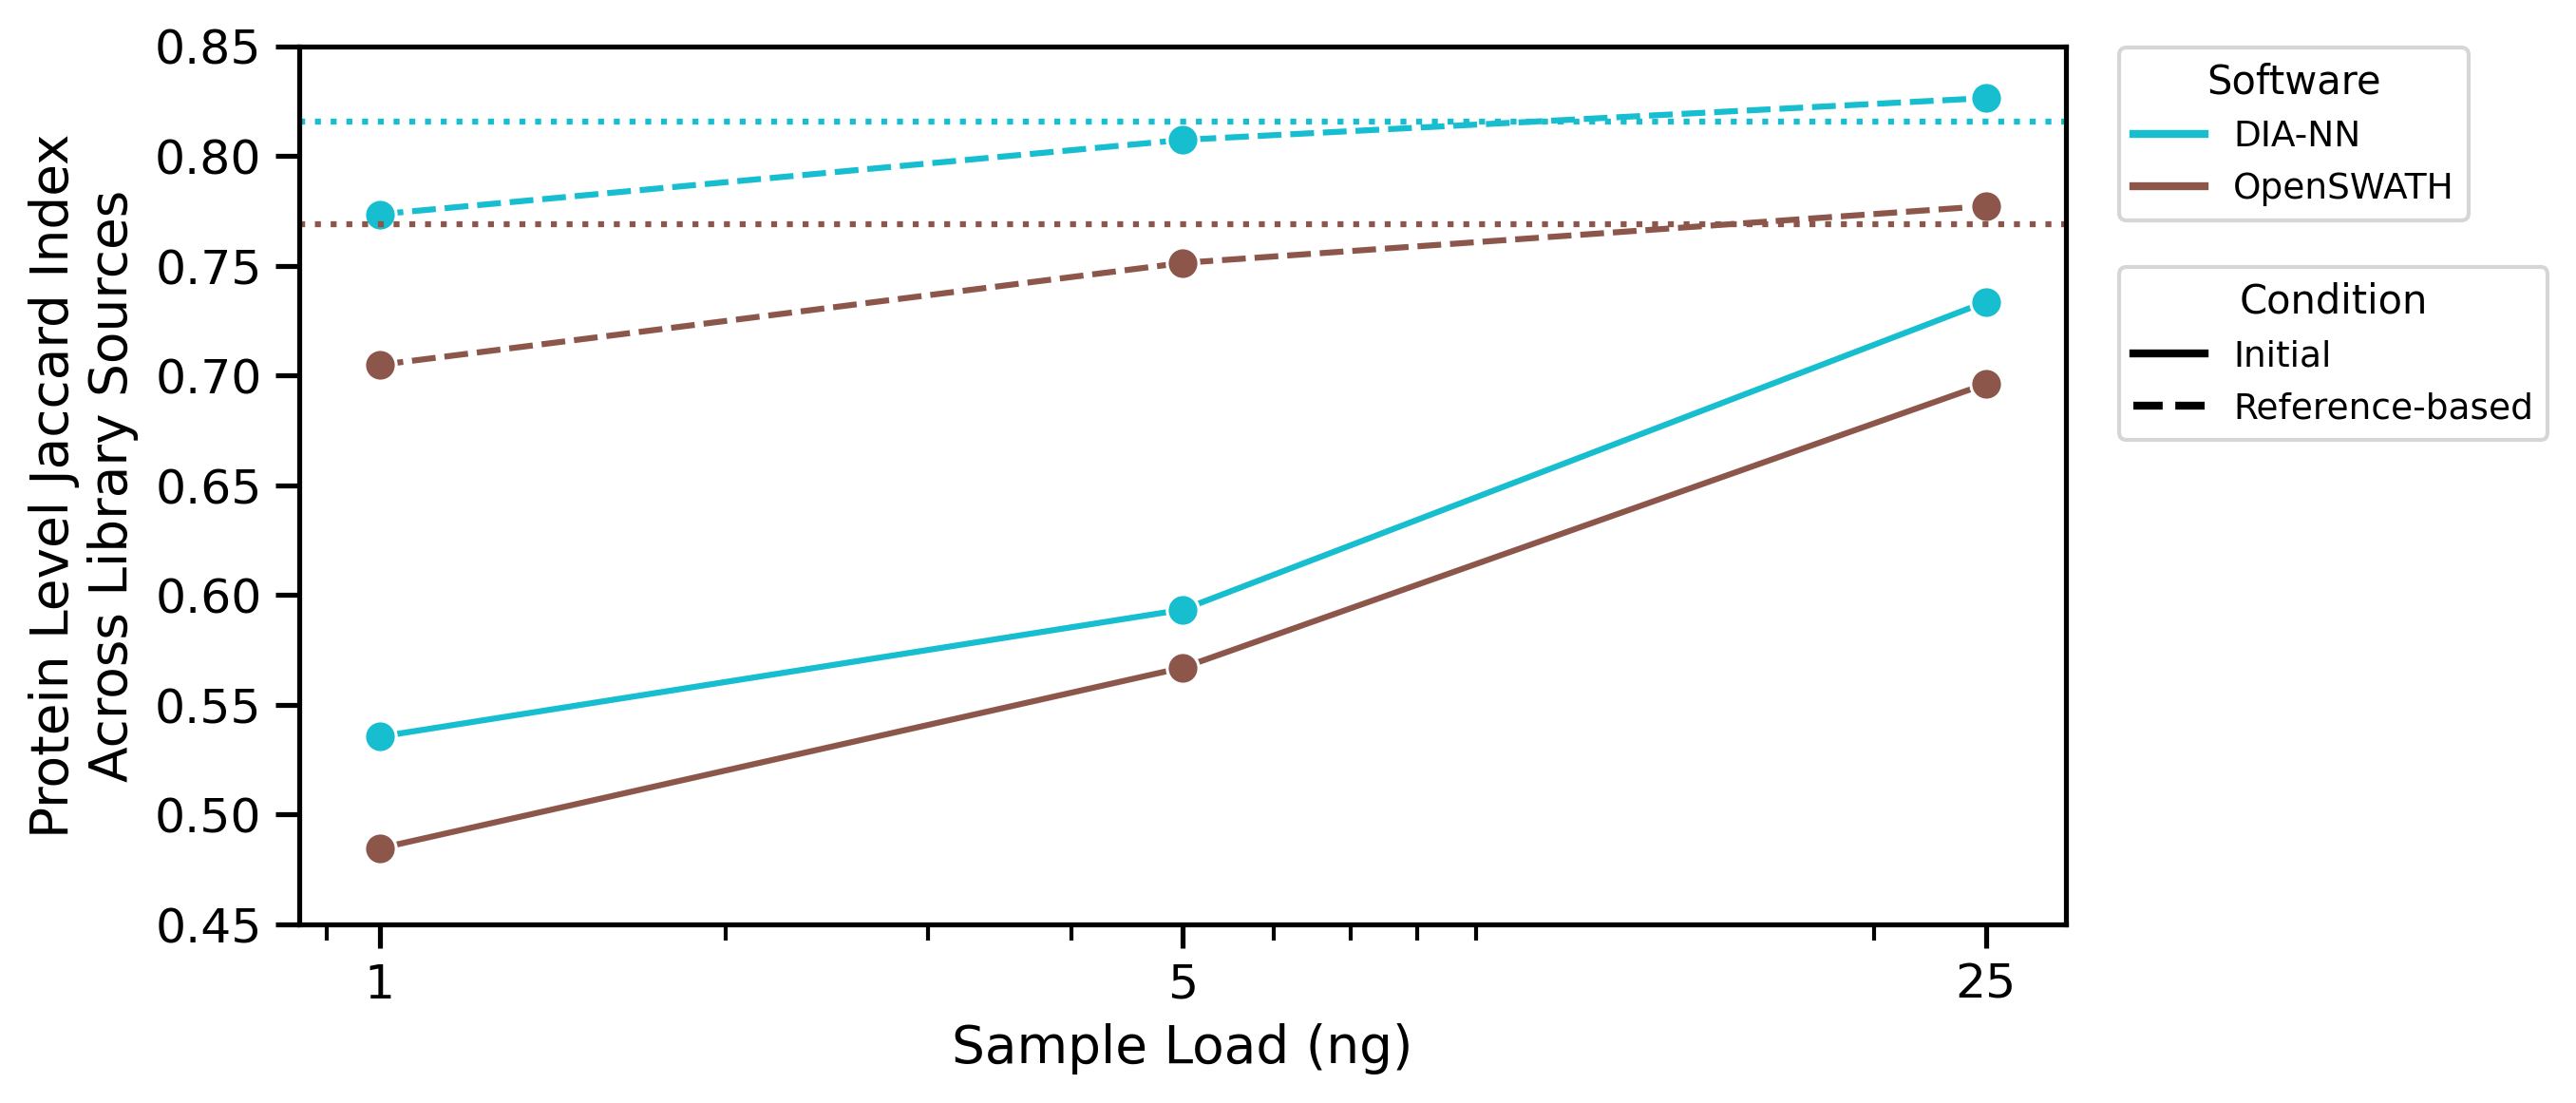

In [16]:
with sns.plotting_context('notebook', font_scale=1.1):
    plt.figure(figsize=(8, 4), dpi=300)
    ax = sns.lineplot(data=rslts, x='Dilution', hue='Software', style='Condition', 
                     y='Jaccard Index', marker='o', markersize=8, style_order=['Initial', 'Reconstructed'])
    
    plt.xscale('log')
    plt.xticks([1, 5, 25], ['1', '5', '25'])
    plt.xlabel('Sample Load (ng)')
    plt.ylabel("Protein Level Jaccard Index\nAcross Library Sources")
    
    # Remove the automatic legend
    ax.legend().remove()
    
    # Create separate legends
    software_colors = {'DIA-NN': 'tab:cyan', 'OpenSWATH': 'tab:brown'}
    condition_styles = {'Initial': '-', 'Reference-based': '--'}
    
    # Create software legend (colors)
    software_handles = [plt.Line2D([0], [0], color=color, linewidth=2, label=software) 
                       for software, color in software_colors.items()]
    legend1 = ax.legend(handles=software_handles, title='Software', 
                        loc='center left', fontsize=9, title_fontsize=10, 
                        bbox_to_anchor=(1.02, 0.9))
    
    # Create condition legend (line styles)
    condition_handles = [plt.Line2D([0], [0], color='black', linestyle=style, linewidth=2, label=condition)
                        for condition, style in condition_styles.items()]
    legend2 = ax.legend(handles=condition_handles, title='Condition', 
                        loc='center left', fontsize=9, title_fontsize=10,
                        bbox_to_anchor=(1.02, 0.65))
    
    ax.axhline(rslts_diann_100ng_initial, color=software_colors['DIA-NN'], ls='dotted')
    ax.axhline(rslts_osw_100ng_initial, color=software_colors['OpenSWATH'], ls='dotted')
    
    # Add the first legend back
    ax.add_artist(legend1)
    ax.set_ylim(0.45, 0.85)
    
    plt.savefig("Figure-S11.png", dpi=300, bbox_inches='tight')

In [17]:
rslts

,Condition,Dilution,Jaccard Index,Software
0,Initial,1,0.535437,DIA-NN
1,Reconstructed,1,0.773475,DIA-NN
2,Initial,5,0.593299,DIA-NN
3,Reconstructed,5,0.807365,DIA-NN
4,Initial,25,0.733504,DIA-NN
5,Reconstructed,25,0.826417,DIA-NN
0,Initial,1,0.484547,OpenSWATH
1,Reconstructed,1,0.704833,OpenSWATH
2,Initial,5,0.566888,OpenSWATH
3,Reconstructed,5,0.751304,OpenSWATH


In [18]:
percent_increase(0.48, rslts_osw_100ng_initial)

60.21696262050895

In [19]:
percent_increase(0.53, rslts_diann_100ng_initial)

53.87291572654593

In [20]:
percent_increase(0.48, 0.70)

45.83333333333333

In [21]:
percent_increase(0.53, 0.77)

45.283018867924525

In [22]:
percent_increase(0.775166, 0.961494)

24.037173973058664